In [1]:
# Cell 1: Imports and setup
import json
import os
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# FONT — Fira Code for all plots in this notebook
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Fira Code'
plt.rcParams['font.monospace'] = ['Fira Code']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Fira Code'
plt.rcParams['mathtext.it'] = 'Fira Code'
plt.rcParams['mathtext.bf'] = 'Fira Code'


In [3]:
# Cell 2: Load ACE-based aggregated datasets (using _ace.json files)
collections = ['lastfm', 'suno', 'udio']
base_path = "/workspace/ngram_datasets/trigrams"

def normalize_functional_ngram(entry):
    functional = entry.get("function") or entry.get("functional")
    if not functional:
        fh = entry.get("functional_harmony", {})
        if isinstance(fh, dict):
            functional = fh.get("functional")
    if isinstance(functional, str):
        functional = functional.split()
    if functional:
        entry["ngram"] = list(functional)

# Load all collection data from ACE files
all_trigram_data = {}
for collection in collections:
    file_path = f"{base_path}/3gram_dataset_{collection}_ace.json"  # ACE version
    with open(file_path, 'r') as f:
        all_trigram_data[collection] = json.load(f)
    for entry in all_trigram_data[collection]:
        normalize_functional_ngram(entry)

print("Loaded ACE trigram datasets:")
for collection in collections:
    print(f"{collection}: {len(all_trigram_data[collection])} unique trigrams")

Loaded ACE trigram datasets:
lastfm: 28573 unique trigrams
suno: 16920 unique trigrams
udio: 24893 unique trigrams


In [4]:
# Cell 3: Convert to trigram_counts format for basic visualizations
trigram_counts = {}

for collection in collections:
    trigram_counts[collection] = Counter()
    
    # Convert from new format to old format
    for entry in all_trigram_data[collection]:
        trigram_tuple = tuple(entry["ngram"])  # Convert list back to tuple
        count = entry["count"]
        trigram_counts[collection][trigram_tuple] = count

print("Converted to visualization format:")
for collection in collections:
    total = sum(trigram_counts[collection].values())
    print(f"{collection}: {total:,} total trigram instances")

Converted to visualization format:
lastfm: 859,882 total trigram instances
suno: 1,052,255 total trigram instances
udio: 608,663 total trigram instances


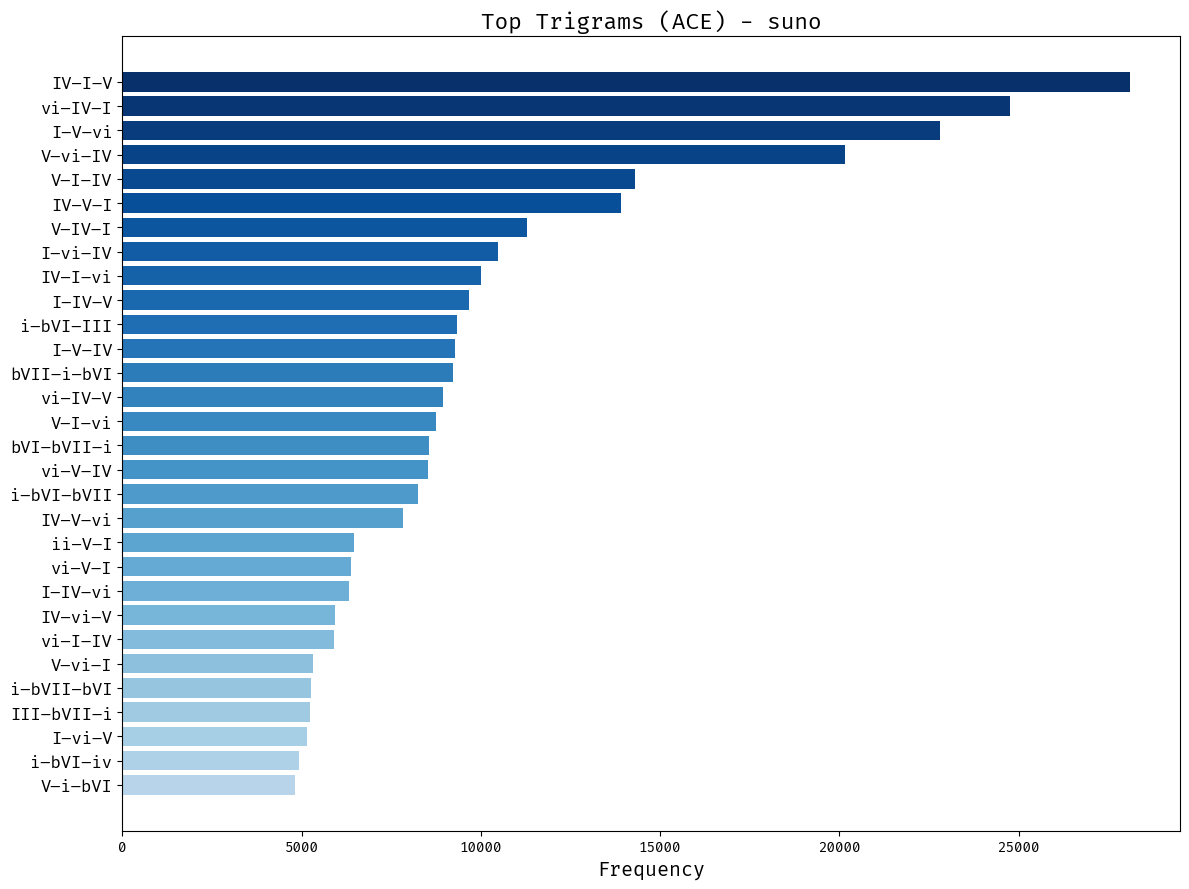

In [5]:
# Cell 4: Single collection visualization (change collection as needed)
collection = 'suno'  # Change this to 'lastfm', 'suno', or 'udio'

# Create sorted_trigram_counts from the loaded data
sorted_trigram_counts = {}
for entry in all_trigram_data[collection]:
    trigram_tuple = tuple(entry["ngram"])
    count = entry["count"]
    sorted_trigram_counts[trigram_tuple] = count

# Get the trigrams and counts from your dictionary
trigrams = list(sorted_trigram_counts.keys())
counts = list(sorted_trigram_counts.values())

# How many to plot? (e.g., top 30)
top_n = 30
plot_trigrams = trigrams[:top_n]
plot_counts = counts[:top_n]

# Turn trigrams into readable strings
trigram_labels = ['–'.join(tri) for tri in plot_trigrams]

# Plot with blue color map
plt.figure(figsize=(12, 9))
bars = plt.barh(range(top_n), plot_counts[::-1], color=plt.cm.Blues(np.linspace(0.3, 1, top_n)))
plt.yticks(range(top_n), trigram_labels[::-1], fontsize=12)
plt.xlabel("Frequency", fontsize=14)
plt.title("Top Trigrams (ACE) - " + collection, fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
# Cell 4b: Are these progressions the same under key rotation?
import re

degree_map = {
    "I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6, "VII": 7
}

def normalize_roman(token):
    token = token.split("/")[0]
    match = re.match(r"^[b#]*([IViv]+)", token)
    if not match:
        return None
    return match.group(1).upper()

def to_degrees(tokens):
    degrees = []
    for token in tokens:
        base = normalize_roman(token)
        if not base or base not in degree_map:
            return None
        degrees.append(degree_map[base])
    return degrees

def rotate_degrees(degrees, shift):
    return [((d - 1 + shift) % 7) + 1 for d in degrees]

def degrees_to_roman(degrees):
    inv = {v: k for k, v in degree_map.items()}
    return [inv[d] for d in degrees]

progression_a = ["iii", "I", "V"]
progression_b = ["I", "IV", "vi"]

deg_a = to_degrees(progression_a)
deg_b = to_degrees(progression_b)

print("progression_a", progression_a, "->", deg_a)
print("progression_b", progression_b, "->", deg_b)

matches = []
for shift in range(7):
    rotated = rotate_degrees(deg_b, shift)
    if rotated == deg_a:
        matches.append(shift)

if matches:
    print("Match under rotation(s):", matches)
    for shift in matches:
        print("  rotated progression_b ->", degrees_to_roman(rotate_degrees(deg_b, shift)))
else:
    print("No diatonic key rotation maps progression_b to progression_a.")
    print("All rotations of progression_b:")
    for shift in range(7):
        print("  shift", shift, "->", degrees_to_roman(rotate_degrees(deg_b, shift)))

# Concrete chord examples in C major for intuition
c_major_map = {
    "I": "C", "II": "D", "III": "E", "IV": "F", "V": "G", "VI": "A", "VII": "B"
}
print("C major chords:")
print("  iii I V ->", [c_major_map[normalize_roman(x)] for x in progression_a])
print("  I V vi ->", [c_major_map[normalize_roman(x)] for x in progression_b])

progression_a ['iii', 'I', 'V'] -> [3, 1, 5]
progression_b ['I', 'IV', 'vi'] -> [1, 4, 6]
No diatonic key rotation maps progression_b to progression_a.
All rotations of progression_b:
  shift 0 -> ['I', 'IV', 'VI']
  shift 1 -> ['II', 'V', 'VII']
  shift 2 -> ['III', 'VI', 'I']
  shift 3 -> ['IV', 'VII', 'II']
  shift 4 -> ['V', 'I', 'III']
  shift 5 -> ['VI', 'II', 'IV']
  shift 6 -> ['VII', 'III', 'V']
C major chords:
  iii I V -> ['E', 'C', 'G']
  I V vi -> ['C', 'F', 'A']


In [7]:
# Cell 4c: Sanity check pop progressions vs ACE functional labels
collection = "suno"

def trigram_counter(entries, normalize=None):
    counter = Counter()
    for entry in entries:
        tri = tuple(entry["ngram"])
        if normalize:
            tri = normalize(tri)
        counter[tri] += entry["count"]
    return counter

def upper_tri(tri):
    return tuple(t.upper() for t in tri)

raw_counts = trigram_counter(all_trigram_data[collection])
upper_counts = trigram_counter(all_trigram_data[collection], normalize=upper_tri)

print("Top 10 raw trigrams (case preserved):")
for tri, cnt in raw_counts.most_common(10):
    print(" ", tri, cnt)

print("\nTop 10 trigrams (uppercased):")
for tri, cnt in upper_counts.most_common(10):
    print(" ", tri, cnt)

print("\nUnique trigrams (raw vs uppercased):", len(raw_counts), "->", len(upper_counts))

targets = [
    ("IV", "I", "V"),
    ("IV", "I", "v"),
    ("vi", "IV", "I"),
    ("V", "I", "IV"),
    ("v", "I", "VI"),
    ("I", "V", "vi"),
    ("iii", "I", "V"),
    ("II", "iii", "I"),
    ("I", "V", "II"),
    ("V", "ii", "II"),
    ("I", "V", "vi"),
    ("ii", "I", "II"),
 ]

print("\nTarget counts in raw ACE labels:")
for tri in targets:
    print(" ", tri, raw_counts.get(tri, 0))

print("\nTarget counts with uppercase normalization:")
for tri in targets:
    print(" ", tuple(t.upper() for t in tri), upper_counts.get(tuple(t.upper() for t in tri), 0))

Top 10 raw trigrams (case preserved):
  ('IV', 'I', 'V') 28093
  ('vi', 'IV', 'I') 24768
  ('I', 'V', 'vi') 22803
  ('V', 'vi', 'IV') 20162
  ('V', 'I', 'IV') 14290
  ('IV', 'V', 'I') 13900
  ('V', 'IV', 'I') 11276
  ('I', 'vi', 'IV') 10486
  ('IV', 'I', 'vi') 10002
  ('I', 'IV', 'V') 9670

Top 10 trigrams (uppercased):
  ('IV', 'I', 'V') 36101
  ('IV', 'V', 'I') 27954
  ('V', 'I', 'IV') 26848
  ('VI', 'IV', 'I') 26422
  ('I', 'V', 'VI') 25248
  ('V', 'VI', 'IV') 22607
  ('I', 'IV', 'V') 17686
  ('V', 'IV', 'I') 15962
  ('I', 'V', 'IV') 13670
  ('II', 'V', 'I') 11993

Unique trigrams (raw vs uppercased): 16920 -> 4707

Target counts in raw ACE labels:
  ('IV', 'I', 'V') 28093
  ('IV', 'I', 'v') 2648
  ('vi', 'IV', 'I') 24768
  ('V', 'I', 'IV') 14290
  ('v', 'I', 'VI') 42
  ('I', 'V', 'vi') 22803
  ('iii', 'I', 'V') 776
  ('II', 'iii', 'I') 627
  ('I', 'V', 'II') 1090
  ('V', 'ii', 'II') 0
  ('I', 'V', 'vi') 22803
  ('ii', 'I', 'II') 0

Target counts with uppercase normalization:
  ('IV

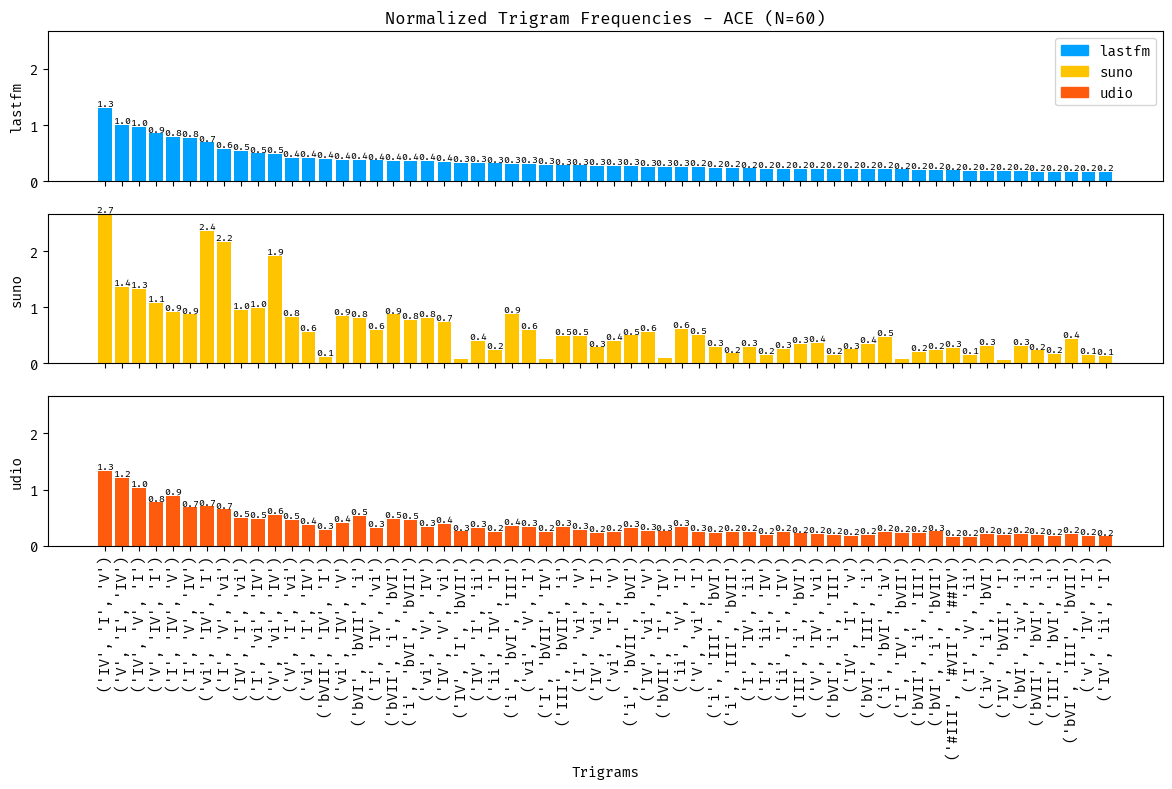

lastfm: 859,882 total trigrams
suno: 1,052,255 total trigrams
udio: 608,663 total trigrams


In [8]:
# Cell 5: Multi-collection comparison visualization
N = 60
lastfm_trigrams = [tuple(entry["ngram"]) for entry in all_trigram_data["lastfm"][:N]]

# Prepare data for each collection in this fixed order
freq_matrix = []
for col in collections:
    col_counts = []
    for tri in lastfm_trigrams:
        col_counts.append(trigram_counts[col][tri])
    freq_matrix.append(col_counts)

# Normalize by total trigrams per collection (relative frequency)
total_trigrams = [sum(trigram_counts[col].values()) for col in collections]

# Normalize each row by its total
normalized_freq_matrix = []
for idx, col_counts in enumerate(freq_matrix):
    normalized_counts = [count / total_trigrams[idx] * 100 for count in col_counts]
    normalized_freq_matrix.append(normalized_counts)

# Use normalized data
freq_matrix = normalized_freq_matrix
max_count = max([max(col_counts) for col_counts in freq_matrix])

colors = ["#00A2FF", "#FFC400", "#FF5B0E"]
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=colors[i], label=collections[i]) for i in range(3)]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for idx, col in enumerate(collections):
    axes[idx].bar(range(N), freq_matrix[idx], color=colors[idx])
    axes[idx].set_ylabel(f'{collections[idx]}')
    axes[idx].set_ylim(0, max_count)
    
    if idx == 0:
        axes[idx].set_title(f"Normalized Trigram Frequencies - ACE (N={N})")
    
    # Add count labels on bars (show as percentage)
    for i, count in enumerate(freq_matrix[idx]):
        if count > 0.1:  # Only show if > 0.1%
            axes[idx].text(i, count, f'{count:.1f}', ha='center', va='bottom', fontsize=7)

# Set x-axis labels only on bottom plot
axes[-1].set_xticks(range(N))
axes[-1].set_xticklabels([str(tri) for tri in lastfm_trigrams], rotation=90)
axes[-1].set_xlabel("Trigrams")

# Add legend to top plot
axes[0].legend(
    handles=legend_handles,
    loc='upper right',
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.show()

# Print normalization info
for idx, col in enumerate(collections):
    print(f"{col}: {total_trigrams[idx]:,} total trigrams")

In [9]:
# Cell 6: Convert aggregated data to data_entries format (using HUMAN styles)
data_entries = []

for collection in collections:
    for trigram_entry in all_trigram_data[collection]:
        trigram_tuple = tuple(trigram_entry["ngram"])
        
        # Use HUMAN STYLES (original annotations)
        for style, count in trigram_entry["human_styles"]:
            # Create entries based on the actual count of this style for this trigram
            for _ in range(count):
                data_entries.append({
                    "collection": collection,
                    "original_style": style,  # Use original_style for human annotations
                    "trigrams": [trigram_tuple]
                })

print(f"Recreated data_entries with {len(data_entries)} human style-trigram relationships")

# Cell 7: Style-based trigram analysis (using human styles)
source = "original_style"  # Use original_style for human annotations

# Step 1: Get list of genres (top 8) you want to plot
genre_counts = Counter(entry[source] for entry in data_entries if entry[source])
top_genres = [g for g, _ in genre_counts.most_common(8)]

print("Top 8 human-annotated genres:", top_genres)

# Step 2: Aggregate trigrams per (genre, collection)
trigram_counts_by_style = defaultdict(lambda: defaultdict(Counter))

for entry in data_entries:
    genre = entry[source]
    if genre not in top_genres:
        continue
    collection = entry['collection']
    for trigram in entry['trigrams']:
        trigram_counts_by_style[genre][collection][trigram] += 1
        
# Step 1: Get list of genres (top 8) you want to plot
genre_counts = Counter(entry[source] for entry in data_entries if entry[source])
top_genres = [g for g, _ in genre_counts.most_common(8)]

print("Top 8 human-annotated genres:", top_genres)

Recreated data_entries with 6684139 human style-trigram relationships
Top 8 human-annotated genres: ['rock', 'pop', 'metal', 'electronic', 'folk', 'indie', 'punk', 'dance']
Top 8 human-annotated genres: ['rock', 'pop', 'metal', 'electronic', 'folk', 'indie', 'punk', 'dance']


In [10]:
# Cell 6 Version D: Use ALL Dortmund genres proportionally
data_entries = []

for collection in collections:
    for trigram_entry in all_trigram_data[collection]:
        trigram_tuple = tuple(trigram_entry["ngram"])
        trigram_count = trigram_entry["count"]
        
        # Use ALL DORTMUND GENRES proportionally
        total_dortmund_weight = sum(weight for genre, weight in trigram_entry["dortmund_genres"])
        
        if total_dortmund_weight > 0:
            for genre, weight in trigram_entry["dortmund_genres"]:
                # Calculate proportion of this genre
                proportion = weight / total_dortmund_weight
                
                # Assign proportional count (round to nearest integer)
                genre_count = round(trigram_count * proportion)
                
                if genre_count > 0:
                    for _ in range(genre_count):
                        data_entries.append({
                            "collection": collection,
                            "top_genre_1": genre,
                            "trigrams": [trigram_tuple]
                        })

print(f"Recreated data_entries with {len(data_entries)} entries using ALL Dortmund genres proportionally")

# Check genre distribution
source = "top_genre_1"
genre_counts = Counter(entry[source] for entry in data_entries if entry[source])
print("\nTop 12 genres and their counts:")
for genre, count in genre_counts.most_common(12):
    print(f"  {genre}: {count:,}")

Recreated data_entries with 2490292 entries using ALL Dortmund genres proportionally

Top 12 genres and their counts:
  rock: 799,498
  electronic: 362,465
  pop: 338,485
  jazz: 325,303
  country: 265,414
  hiphop: 213,454
  soul: 102,215
  blues: 83,458


Created data_entries_human with 6684139 human style-trigram relationships
Top 8 human-annotated genres: ['rock', 'pop', 'metal', 'electronic', 'folk', 'indie', 'punk', 'dance']
Created df_long with 480 rows


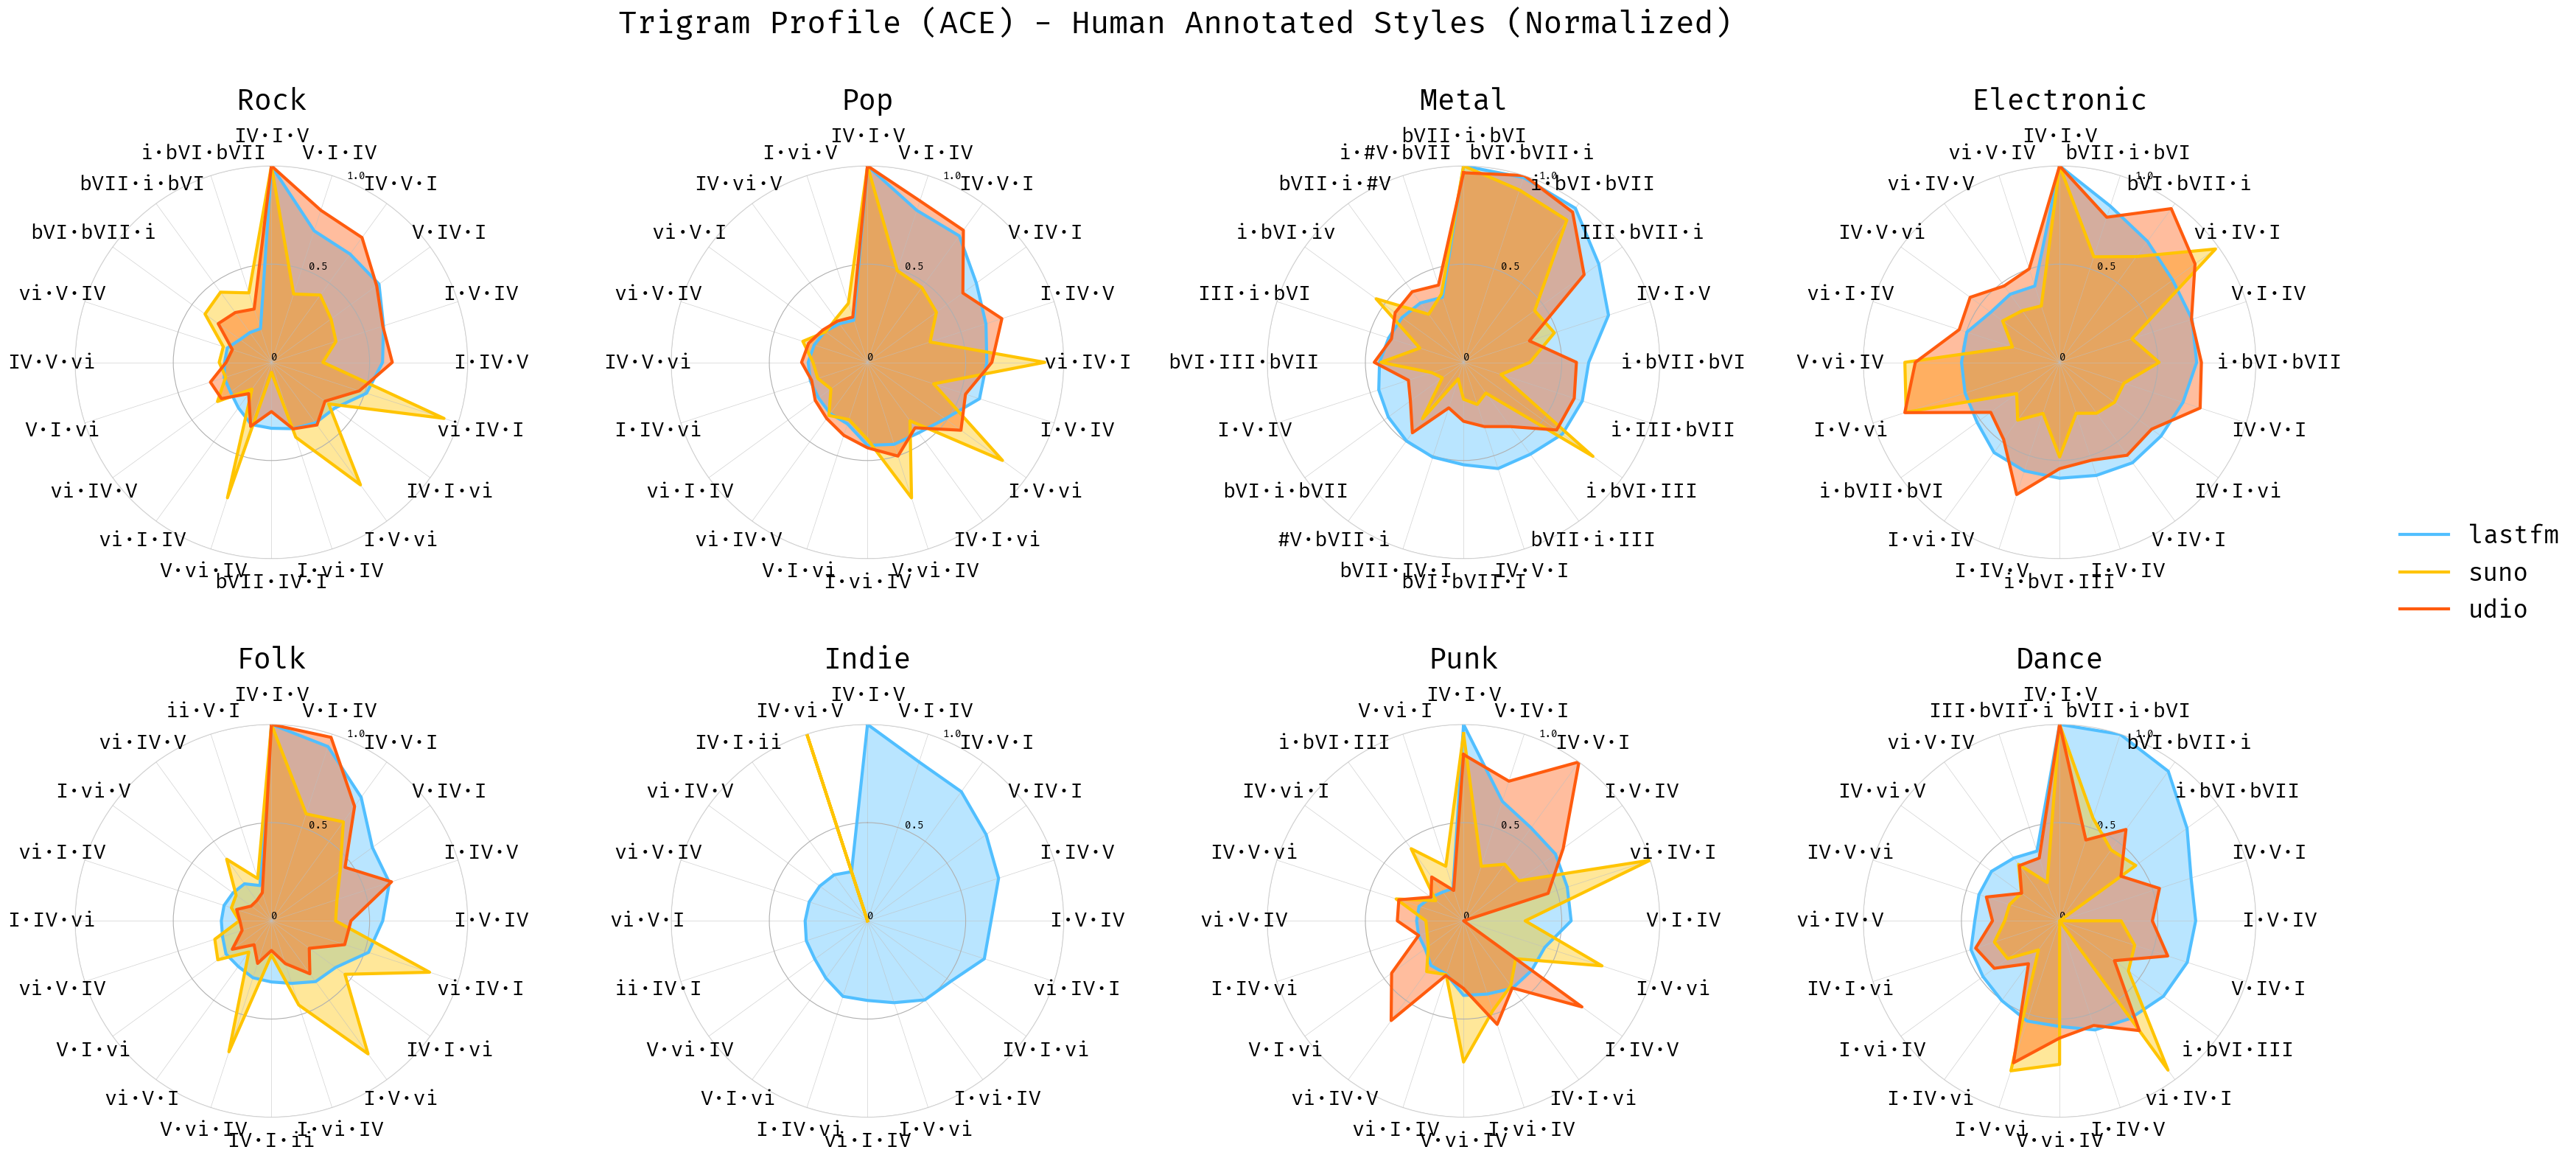

In [11]:
# Rebuild data_entries with HUMAN styles (independent of previous cells)
data_entries_human = []

for collection in collections:
    for trigram_entry in all_trigram_data[collection]:
        trigram_tuple = tuple(trigram_entry["ngram"])
        
        # Use HUMAN STYLES (original annotations)
        for style, count in trigram_entry["human_styles"]:
            for _ in range(count):
                data_entries_human.append({
                    "collection": collection,
                    "original_style": style,
                    "trigrams": [trigram_tuple]
                })

print(f"Created data_entries_human with {len(data_entries_human)} human style-trigram relationships")

# Use human styles
source = "original_style"

# Step 1: Get list of genres (top 8) you want to plot  
genre_counts = Counter(entry[source] for entry in data_entries_human if entry.get(source))
top_genres = [g for g, _ in genre_counts.most_common(8)]

print("Top 8 human-annotated genres:", top_genres)

if not top_genres:
    print("WARNING: No human style data found! Check that human_styles exists in the ACE data.")
else:
    # Step 2: Aggregate trigrams per (genre, collection)
    trigram_counts_by_style = defaultdict(lambda: defaultdict(Counter))

    for entry in data_entries_human:
        genre = entry.get(source)
        if genre not in top_genres:
            continue
        collection = entry['collection']
        for trigram in entry['trigrams']:
            trigram_counts_by_style[genre][collection][trigram] += 1

    # Step 3: Build long-format data for plotting
    all_rows = []

    for genre in top_genres:
        # Union of top 20 trigrams across all collections for this genre
        all_trigrams = Counter()
        for collection in collections:
            all_trigrams += trigram_counts_by_style[genre][collection]
        top20_trigrams = [t for t, _ in all_trigrams.most_common(20)]
        
        # Gather data
        for trigram in top20_trigrams:
            trigram_str = " - ".join(trigram)
            for collection in collections:
                count = trigram_counts_by_style[genre][collection][trigram]
                all_rows.append({
                    "genre": genre,
                    "trigram": trigram_str,
                    "collection": collection,
                    "count": count
                })

    df_long = pd.DataFrame(all_rows)
    print(f"Created df_long with {len(df_long)} rows")

    # Step 4: Normalize each genre in each collection independently
    df_long['normalized_count'] = 0.0

    for genre in df_long['genre'].unique():
        for collection in collections:
            mask = (df_long['genre'] == genre) & (df_long['collection'] == collection)
            genre_collection_data = df_long[mask]
            
            if len(genre_collection_data) > 0:
                max_count = genre_collection_data['count'].max()
                
                if max_count > 0:
                    df_long.loc[mask, 'normalized_count'] = (genre_collection_data['count'] / max_count) * 100

    # Use normalized counts for radar chart
    df_long['profile_ratio'] = df_long['normalized_count'] / 100

    # Step 5: Radar chart for human annotated styles
    import matplotlib.lines as mlines
    colors = ["#51BFFF", "#FFC400", "#FF5B0E"]
    N = 20
    genres = df_long['genre'].unique()
    n_genres = len(genres)
    n_cols = 4
    n_rows = int(np.ceil(n_genres / n_cols))

    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, figsize=(n_cols * 8, n_rows * 8),
        subplot_kw=dict(polar=True)
    )
    axes = axes.flatten()

    reference_collection = "lastfm"
    trigram_order_per_genre = {
        genre: (
            df_long[
                (df_long['genre'] == genre) & (df_long['collection'] == reference_collection)
            ]
            .groupby('trigram')['normalized_count']
            .sum()
            .sort_values(ascending=False)
            .head(N)
            .index.tolist()
        )
        for genre in genres
    }

    for ax_idx, genre in enumerate(genres):
        top_trigrams = trigram_order_per_genre[genre]
        num_vars = len(top_trigrams)
        angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
        angles += angles[:1]
        
        axes[ax_idx].set_theta_offset(np.pi / 2)
        axes[ax_idx].set_theta_direction(-1)
        axes[ax_idx].spines['polar'].set_color("#D5D5D5")
        axes[ax_idx].spines['polar'].set_linewidth(1.0)
        axes[ax_idx].spines['polar'].set_alpha(0.5)
        
        for col, color in zip(collections, colors):
            subset = df_long[(df_long["genre"] == genre) & (df_long["collection"] == col)]
            subset = subset.set_index("trigram")
            data = [subset.loc[t, "profile_ratio"] if t in subset.index else 0 for t in top_trigrams]
            data += data[:1]
            axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=3)
            axes[ax_idx].fill(angles, data, color=color, alpha=0.4)
        
        axes[ax_idx].set_xticks(angles[:-1])
        axes[ax_idx].set_xticklabels([])
        
        for i, (angle, trigram) in enumerate(zip(angles[:-1], top_trigrams)):
            label_radius = 1.15 if i == 0 else 1.12
            axes[ax_idx].text(
                angle, label_radius, str(trigram).replace(' - ', '·'),
                horizontalalignment='center', verticalalignment='center',
                fontsize=20, transform=axes[ax_idx].transData
            )
        
        axes[ax_idx].set_yticks([0, 0.5, 1.0])
        axes[ax_idx].set_yticklabels(['0', '0.5', '1.0'])
        axes[ax_idx].set_ylim(0, 1)
        axes[ax_idx].xaxis.grid(True, color="#BFBFBF", linewidth=0.5, alpha=0.7)
        axes[ax_idx].set_title(f"{genre.title()}", fontsize=28, pad=55)

    for ax in axes[len(genres):]:
        fig.delaxes(ax)

    plt.suptitle("Trigram Profile (ACE) - Human Annotated Styles (Normalized)", fontsize=30)
    plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=5.0, w_pad=3.5)

    line_handles = [
        mlines.Line2D([], [], color=color, linewidth=3, label=col)
        for col, color in zip(collections, colors)
    ]
    fig.legend(
        handles=line_handles,
        labels=collections,
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        fontsize=24,
        frameon=False
    )
    plt.show()

In [12]:
# Cell 7: Style-based trigram analysis (creates top_genres)
source = "top_genre_1"  # Use top_genre_1 for Dortmund genres

# Step 1: Get list of genres (top 8) you want to plot
genre_counts = Counter(entry[source] for entry in data_entries if entry.get(source))
top_genres = [g for g, _ in genre_counts.most_common(8)]

print("Top 8 Dortmund genres:", top_genres)

# Step 2: Aggregate trigrams per (genre, collection)
trigram_counts_by_style = defaultdict(lambda: defaultdict(Counter))

for entry in data_entries:
    genre = entry.get(source)
    if genre not in top_genres:
        continue
    collection = entry['collection']
    for trigram in entry['trigrams']:
        trigram_counts_by_style[genre][collection][trigram] += 1

# Cell 8: Build long-format data for plotting (now top_genres exists)
all_rows = []

for genre in top_genres:
    # Union of top 20 trigrams across all collections for this genre
    all_trigrams = Counter()
    for collection in collections:
        all_trigrams += trigram_counts_by_style[genre][collection]
    top20_trigrams = [t for t, _ in all_trigrams.most_common(20)]
    
    # Gather data
    for trigram in top20_trigrams:
        trigram_str = " - ".join(trigram)
        for collection in collections:
            count = trigram_counts_by_style[genre][collection][trigram]
            all_rows.append({
                "genre": genre,
                "trigram": trigram_str,
                "collection": collection,
                "count": count
            })

df_long = pd.DataFrame(all_rows)

Top 8 Dortmund genres: ['rock', 'electronic', 'pop', 'jazz', 'country', 'hiphop', 'soul', 'blues']


In [13]:
# Normalize each GENRE in each COLLECTION independently
print("Normalizing each genre in each collection independently...")

df_long['normalized_count'] = 0.0

for genre in df_long['genre'].unique():
    print(f"Normalizing genre: {genre}")
    
    for collection in collections:
        # Get data for THIS genre in THIS collection only
        mask = (df_long['genre'] == genre) & (df_long['collection'] == collection)
        genre_collection_data = df_long[mask]
        
        if len(genre_collection_data) > 0:
            # Find the max count for THIS genre in THIS collection
            max_count = genre_collection_data['count'].max()
            
            if max_count > 0:
                # Normalize THIS genre in THIS collection to 0-100
                df_long.loc[mask, 'normalized_count'] = (genre_collection_data['count'] / max_count) * 100

print("Genre-collection normalization complete!")
# Check that each genre-collection has max = 100
for genre in df_long['genre'].unique():
    print(f"\n{genre}:")
    for col in collections:
        subset = df_long[(df_long['genre'] == genre) & (df_long['collection'] == col)]
        if len(subset) > 0:
            max_norm = subset['normalized_count'].max()
            print(f"  {col}: max = {max_norm:.1f}")

# Use normalized counts for radar chart
df_long['profile_ratio'] = df_long['normalized_count'] / 100  # Scale to 0-1

Normalizing each genre in each collection independently...
Normalizing genre: rock
Normalizing genre: electronic
Normalizing genre: pop
Normalizing genre: jazz
Normalizing genre: country
Normalizing genre: hiphop
Normalizing genre: soul
Normalizing genre: blues
Genre-collection normalization complete!

rock:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

electronic:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

pop:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

jazz:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

country:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

hiphop:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

soul:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0

blues:
  lastfm: max = 100.0
  suno: max = 100.0
  udio: max = 100.0


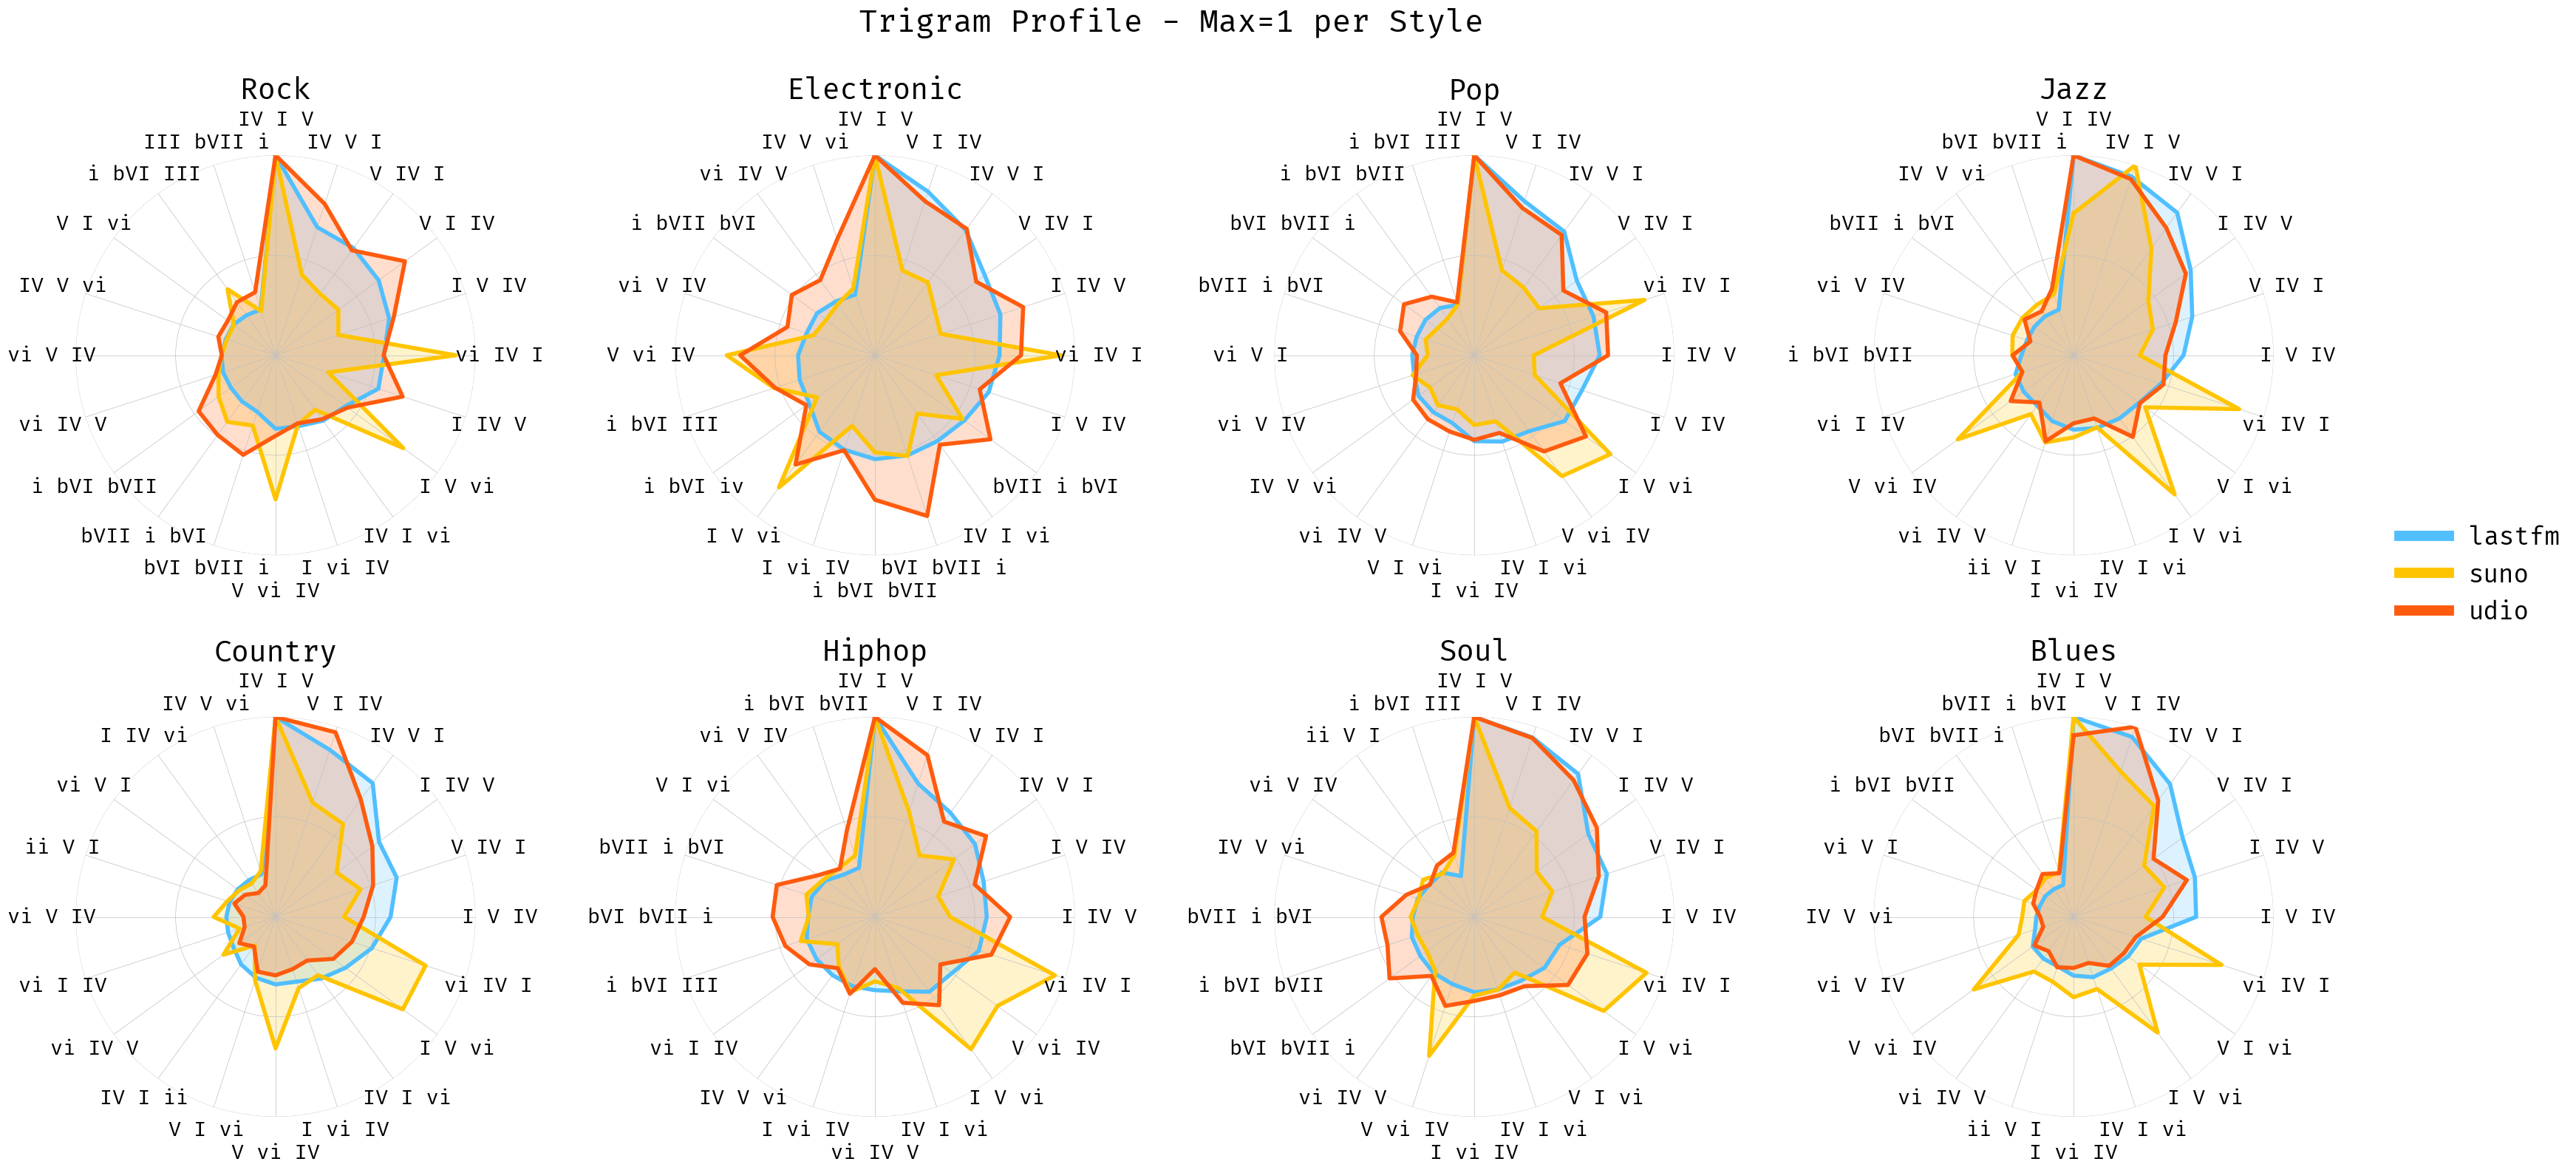

In [14]:
# Radar chart
import matplotlib.lines as mlines

colors = ["#51BFFF", "#FFC400", "#FF5B0E"]
N = 20  # number of trigrams
genres = df_long['genre'].unique()
n_genres = len(genres)
n_cols = 4
n_rows = int(np.ceil(n_genres / n_cols))
line_color = "#C0C0C0"

fig, axes = plt.subplots(
   nrows=n_rows, ncols=n_cols, figsize=(n_cols * 8, n_rows * 8),
   subplot_kw=dict(polar=True)
)
axes = axes.flatten()

# Get trigram order per genre based on lastfm (reference)
reference_collection = "lastfm"
trigram_order_per_genre = {
   genre: (
       df_long[
           (df_long['genre'] == genre) & (df_long['collection'] == reference_collection)
       ]
       .groupby('trigram')['count']
       .sum()
       .sort_values(ascending=False)
       .head(N)
       .index.tolist()
   )
   for genre in genres
}

for ax_idx, genre in enumerate(genres):
    top_trigrams = trigram_order_per_genre[genre]
    num_vars = len(top_trigrams)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    axes[ax_idx].set_theta_offset(np.pi / 2)
    axes[ax_idx].set_theta_direction(-1)

    for col, color in zip(collections, colors):
        subset = df_long[(df_long["genre"] == genre) & (df_long["collection"] == col)]
        subset = subset.set_index("trigram")
        data = [subset.loc[t, "profile_ratio"] if t in subset.index else 0 for t in top_trigrams]
        data += data[:1]
        axes[ax_idx].plot(angles, data, color=color, label=col, linewidth=4)
        axes[ax_idx].fill(angles, data, color=color, alpha=0.2)

    # Set category labels
    axes[ax_idx].set_xticks(angles[:-1])
    axes[ax_idx].set_xticklabels([])  # Clear default labels

    # Manually position labels
    for i, (angle, trigram) in enumerate(zip(angles[:-1], top_trigrams)):
        if i == 0 or i == (num_vars // 2):
            label_radius = 1.18
        else:
            label_radius = 1.12
        axes[ax_idx].text(
            angle, label_radius, str(trigram).replace(' - ', ' '),
            horizontalalignment='center', verticalalignment='center',
            fontsize=20, transform=axes[ax_idx].transData
        )

    axes[ax_idx].set_yticks([0, 0.5, 1.0])
    axes[ax_idx].set_yticklabels(['', '', ''])
    axes[ax_idx].set_ylim(0, 1)

    # === HIDE ALL CIRCLES AND SPOKES HERE ===
    axes[ax_idx].spines['polar'].set_visible(False)  # Hide the outer border
    axes[ax_idx].xaxis.grid(True, color="#C0C0C0", linewidth=0.5, alpha=1.0)  # Spokes in gray
    axes[ax_idx].yaxis.grid(True, color="#C0C0C0", linewidth=0.5, alpha=1.0)  # Circles in gray (if wanted)

    # =========================================

    axes[ax_idx].set_title(f"{genre.title()}", fontsize=28, pad=55)


# Remove any unused axes
for ax in axes[len(genres):]:
   fig.delaxes(ax)

plt.suptitle("Trigram Profile - Max=1 per Style", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=5.0, w_pad=3.5)

line_handles = [
   mlines.Line2D([], [], color=color, linewidth=10, label=col)
   for col, color in zip(collections, colors)
]
fig.legend(
   handles=line_handles,
   labels=collections,
   loc='center left',
   bbox_to_anchor=(1.01, 0.5),
   fontsize=24,
   frameon=False
)
plt.show()

/tmp/ipykernel_1729971/668420332.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_1729971/668420332.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_1729971/668420332.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp/ipykernel_1729971/668420332.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
/tmp

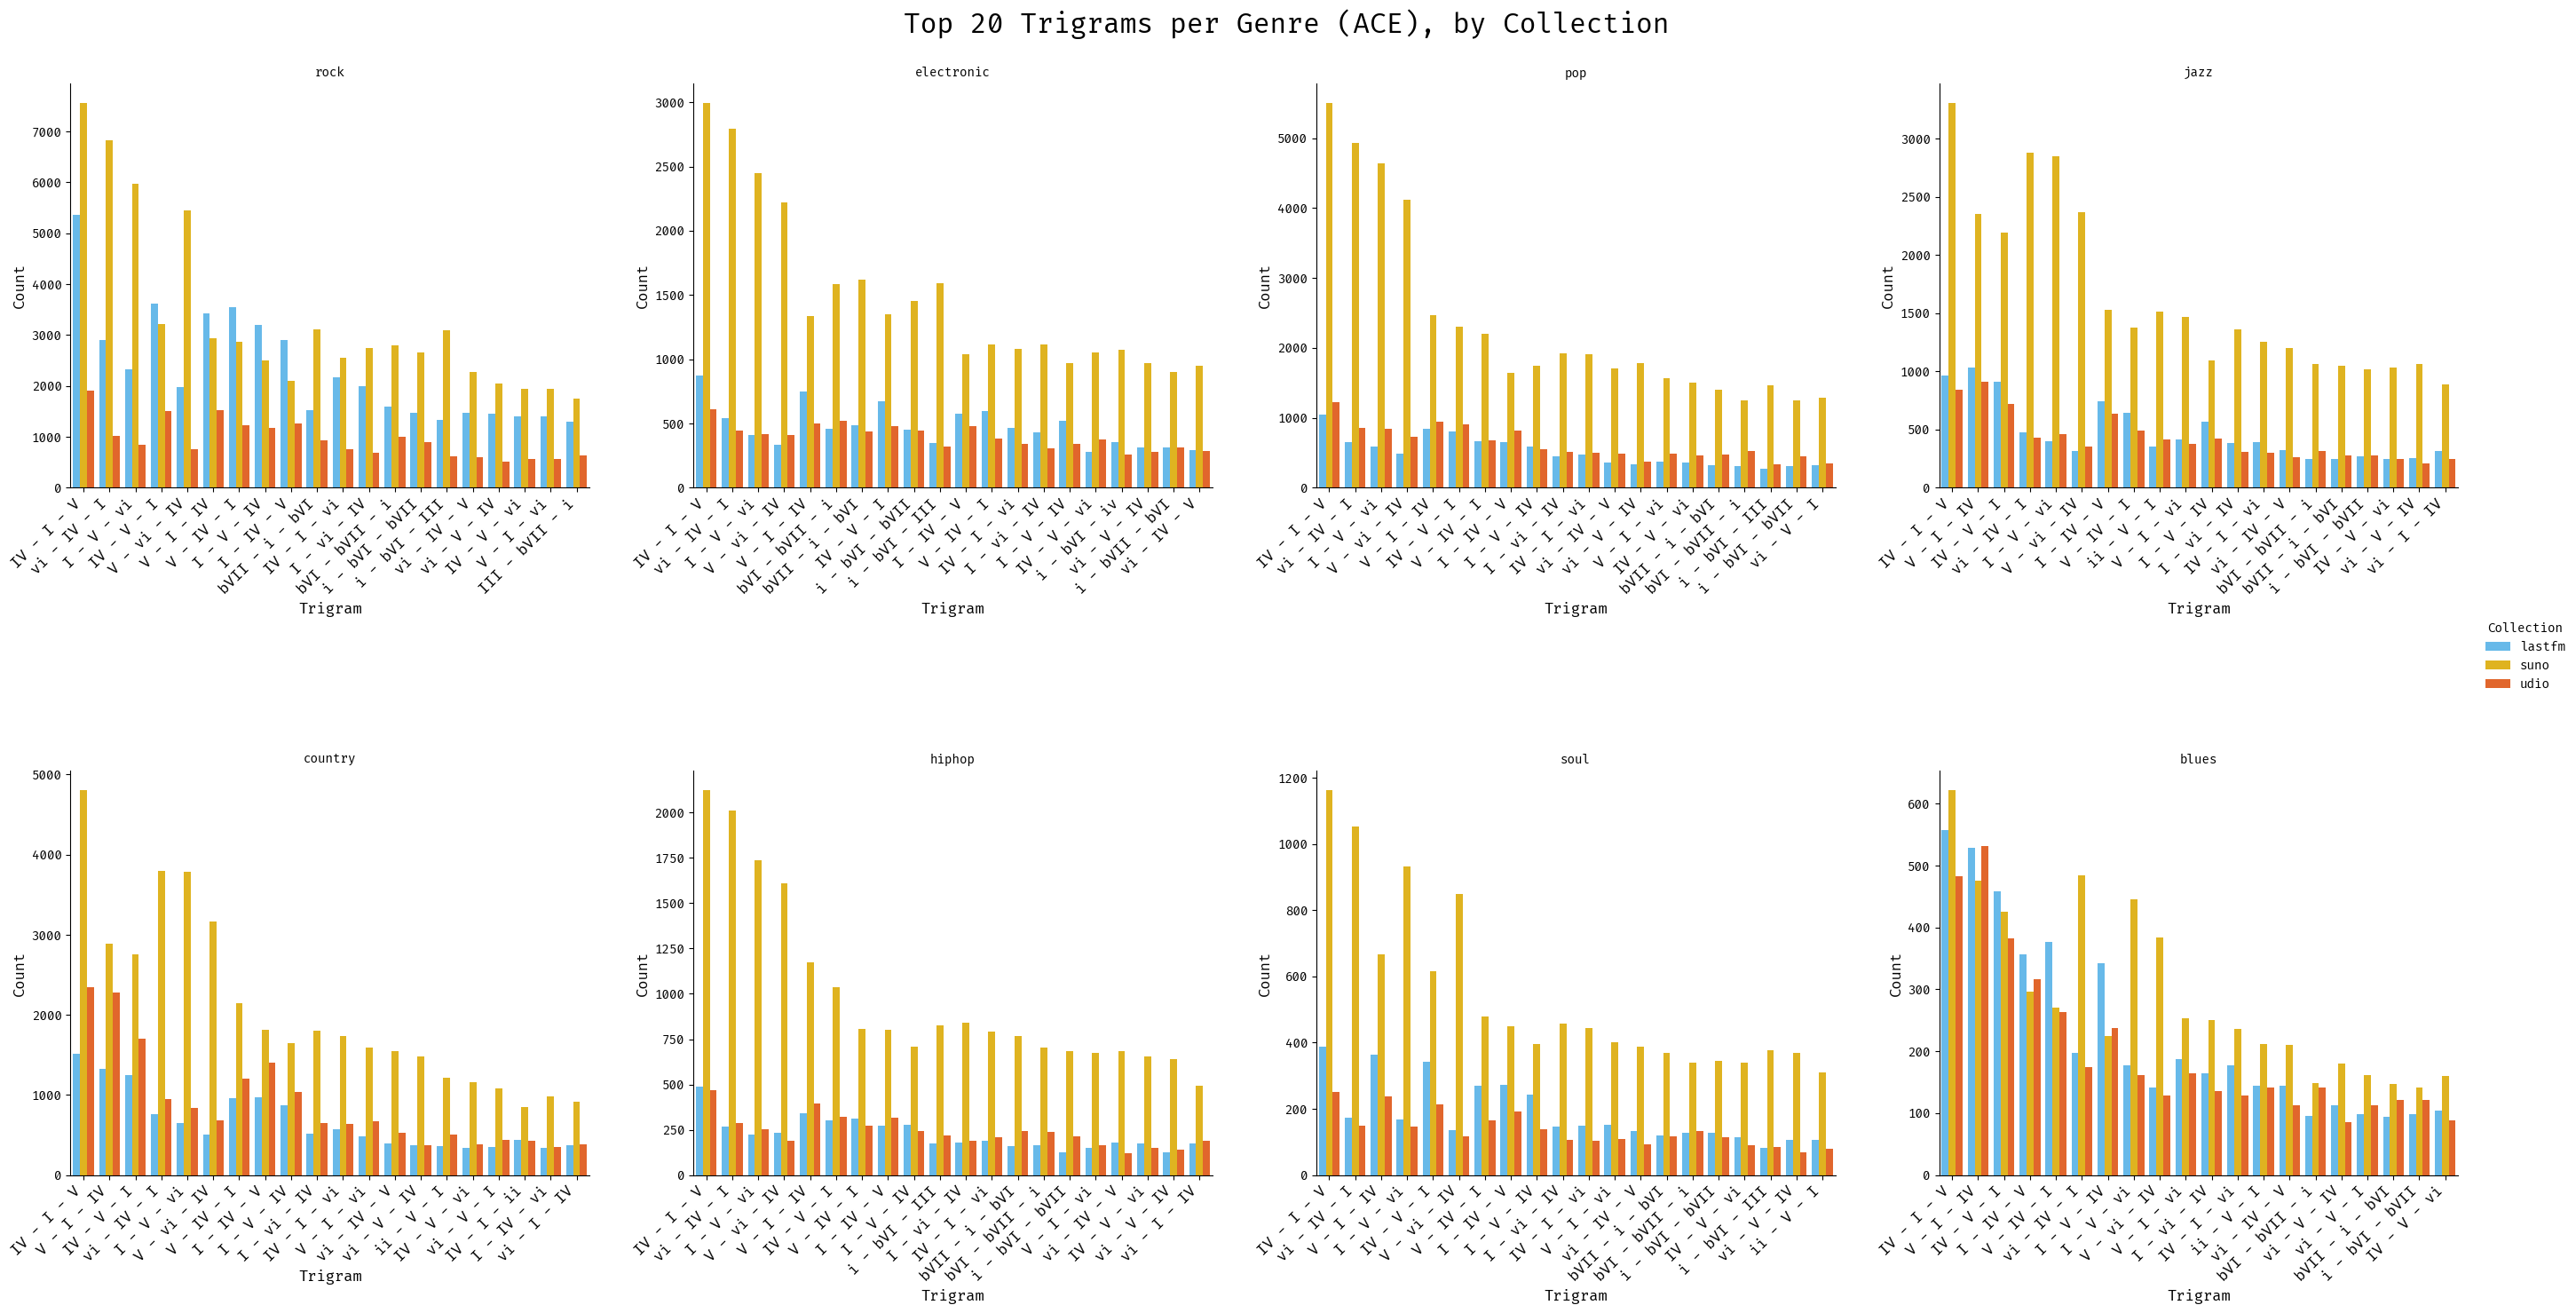

In [15]:
# Cell 9: Style comparison visualization
colors = ["#51BFFF", "#FFC400", "#FF5B0E"]  # lastfm, suno, udio
collection_order = ['lastfm', 'suno', 'udio']
palette = dict(zip(collection_order, colors))

g = sns.FacetGrid(
    df_long, 
    col="genre", 
    col_wrap=4,
    height=7,
    sharex=False, 
    sharey=False
)
g.map_dataframe(
    sns.barplot, 
    x="trigram", 
    y="count", 
    hue="collection", 
    palette=palette,
    hue_order=collection_order
)
g.set_titles("{col_name}", fontsize=16)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    ax.set_xlabel("Trigram", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
g.add_legend(title="Collection")
plt.subplots_adjust(top=0.92, hspace=0.7, wspace=0.2)
plt.suptitle("Top 20 Trigrams per Genre (ACE), by Collection", fontsize=22)
plt.show()

# Cell 10: Normalized radar chart visualization
# Compute the maximum trigram count PER genre (across all collections for that genre)
df_long['max_count_per_genre'] = df_long.groupby('genre')['count'].transform('max')

# Normalize all counts to that maximum, so Y-axis is 0..1
df_long['profile_ratio'] = df_long['count'] / df_long['max_count_per_genre']